In [ ]:
from pathlib import Path

from config import PLOTS_DIR
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

In [ ]:
from core.dgp import DGP_EXAMPLES, ARGARCHProcess

DGP_EXAMPLES["ar_garch"]=lambda: ARGARCHProcess()

## Scenarios and parameter grids

In [ ]:
# name : (dgp_names, model_short_names)
scenarios = {
    "non4": (
        ["iid_t3", "iid_t6"],
        ["iid_student_t"],
    ),
    "efficiency": (
        ["iid_normal"],
        ["iid_normal", "iid_student_t", "iid_nonnormal", "ar1_normal", "ar1_nonnormal"],
    ),
}

parameters = {
    "sr":    [0.5, 1.0, 1.5],
    "T":     [100, 500, 2_000],
    "n_sim": [1_000, 10_000, 50_000],
}

## Experiment registry

In [ ]:
N_SIM  = 30_000
N_JOBS = 8

experiments = {
    "non4": ExperimentSpec(
        scenario   = scenarios["non4"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "efficiency": ExperimentSpec(
        scenario   = scenarios["efficiency"],
        param_name = "n_sim",
        param_values = [100, 1000, 5000, 10_000, 50_000],
        #param_name = "T",
        #param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        T_default=50,
        #n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
}

---
## EXECUTION

In [ ]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        #"non4",
        #"efficiency",
    ],
)


  Experiment: hetero_tails
  [1/3]  T=100  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [2/3]  T=500  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [3/3]  T=2000  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE


---
## VISUALIZATION

In [ ]:
#common
line_plot_kargs = dict(reverse=False, 
                       linewidth=1,)
folder = PLOTS_DIR / "scenarios_add"

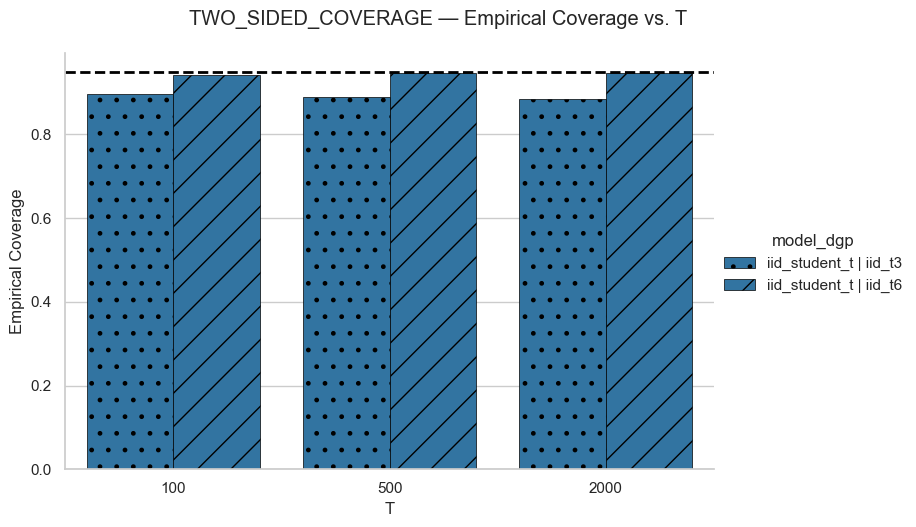

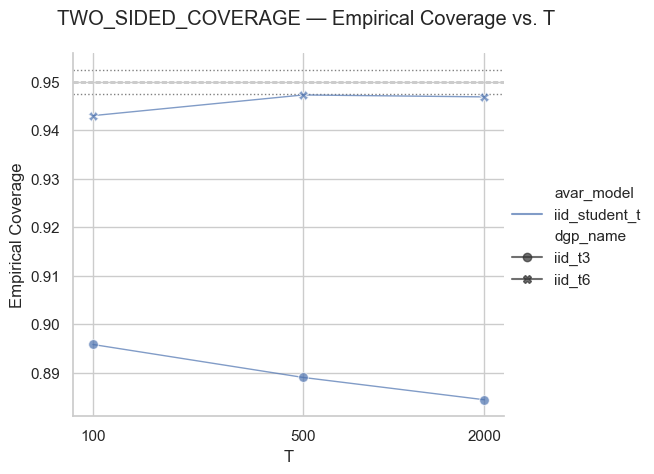

In [ ]:
run_analysis(experiments, "non4", alpha=0.05, plot_mask=[0,1,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, markers=['o', 'X'], xticks=parameters['T']))

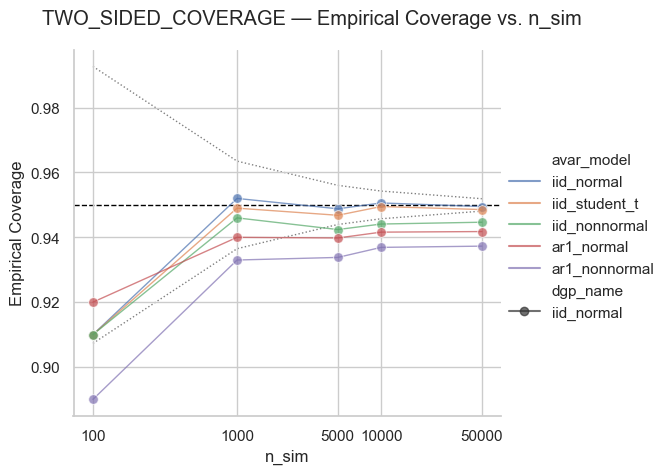

In [ ]:
run_analysis(experiments, "efficiency", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, xticks=[100, 1000, 5000, 10_000, 50_000]))